In [1]:
# Calibration iteration viewer to check convergence

import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm import tqdm

In [26]:
# Session 1
data_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/shortFEBDtoC&T_pcut.bin'
num_rows = os.path.getsize(data_dir) // 6
data = np.memmap(data_dir, dtype = np.int16, mode = 'r', shape=(num_rows, 3))

data_dir2 = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/longFEBDtoC&T_pcut.bin'
num_rows = os.path.getsize(data_dir2) // 6
#data = np.memmap(data_dir2, dtype = np.int16, mode = 'r', shape=(num_rows, 3))
# Location of iteration tsv's
#tsv_dir = '/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/tsvsHighInt'
tsv_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/tsvss'
num_tsvs = 20


# Output images
#image_out_dir = '/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/calibrationimagesHighInt'
image_out_dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET'

In [27]:
out_dir = f'/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/cal10.bin'
if os.path.exists(out_dir):
    os.remove(out_dir)
lookup = np.genfromtxt(os.path.join(tsv_dir, f'time_offset_calibrationit10.tsv'), delimiter = '\t')[:,4]
    
for i in tqdm(range(0, num_rows, 1000000), desc = 'Read chunk', leave = False):
    chunk = np.copy(data[i:i+1000000])
    for row in chunk:
        row[2] = row[2] - lookup[row[0] + 128] + lookup[row[1]]
    with open(out_dir, 'ab') as f:
        chunk.tofile(f)

Number of overflows: 0


Number of overflows: 0


Number of overflows: 0


Number of overflows: 0


Number of overflows: 0


...

Number of overflows: 0


Number of overflows: 0


Number of overflows: 0


/tmp/ipykernel_83502/2212865763.py:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(it+1)


Number of overflows: 0


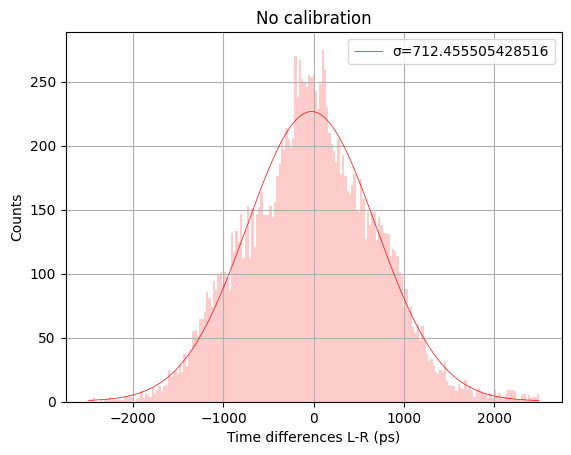

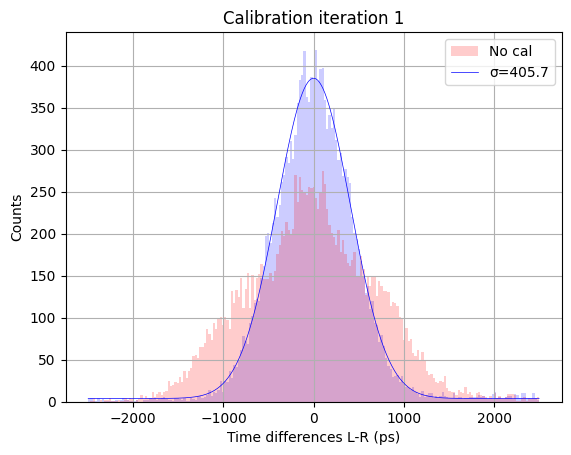

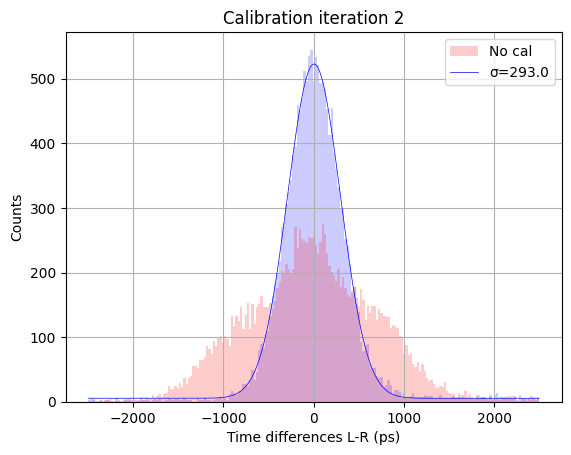

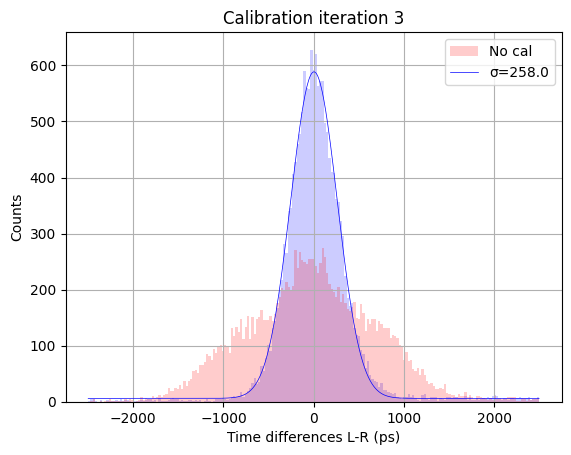

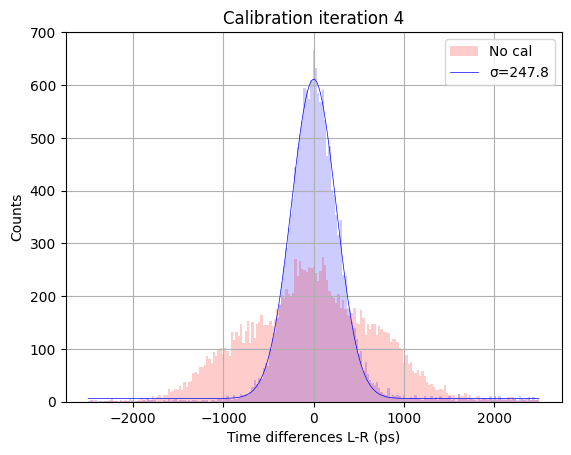

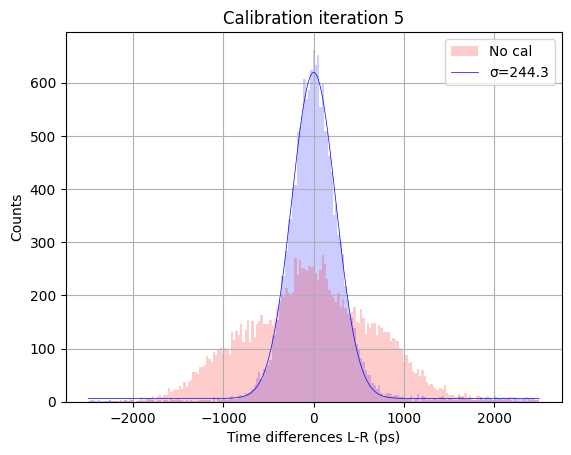

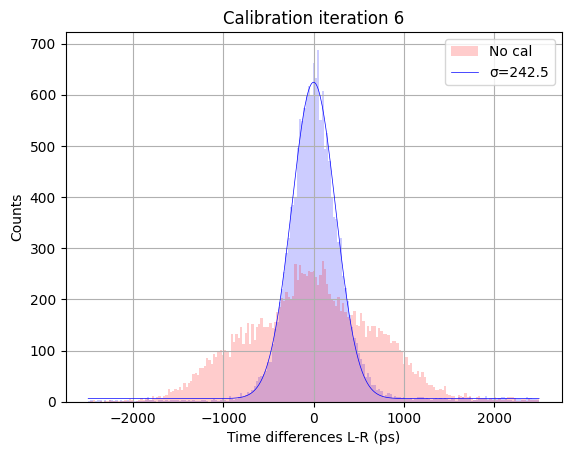

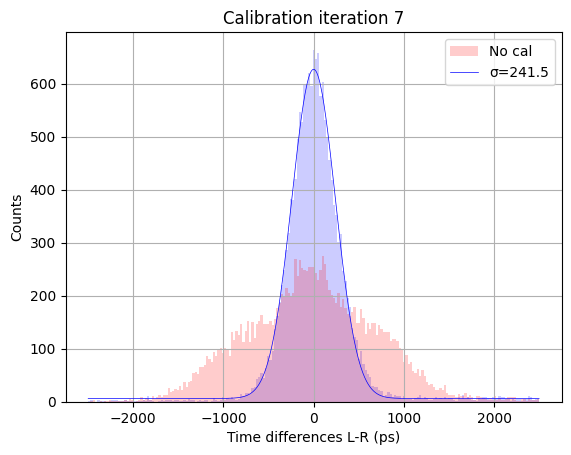

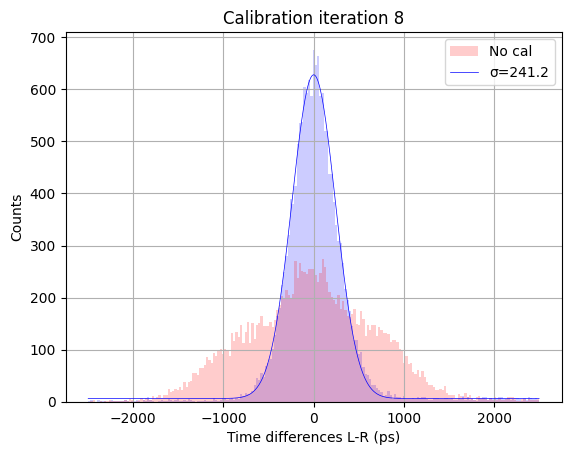

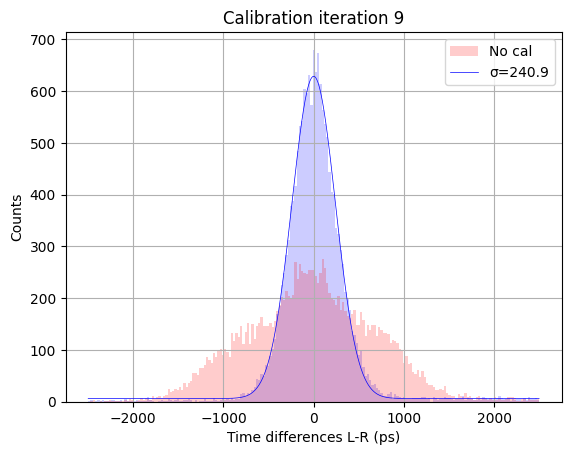

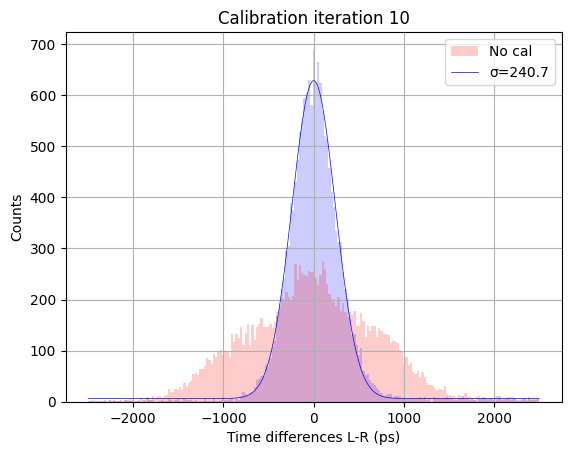

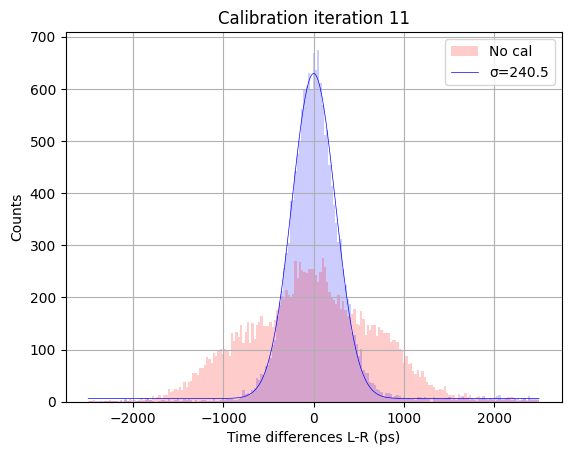

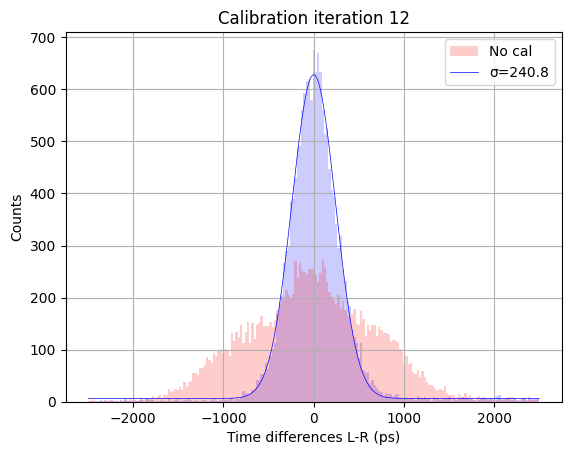

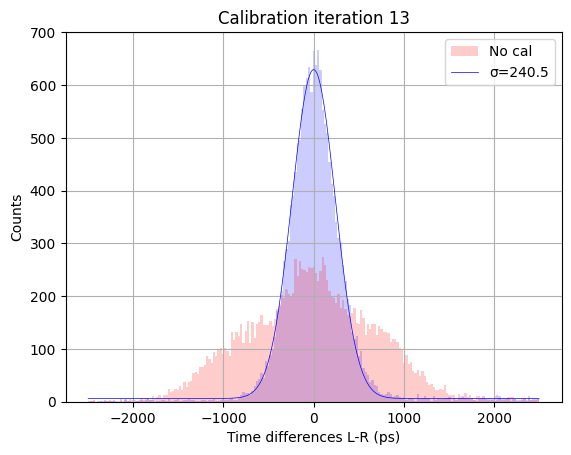

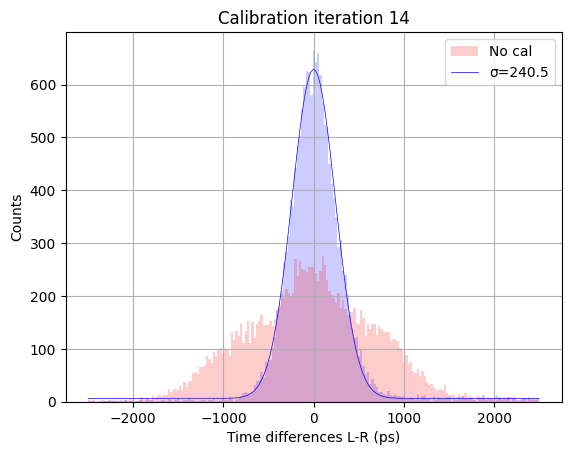

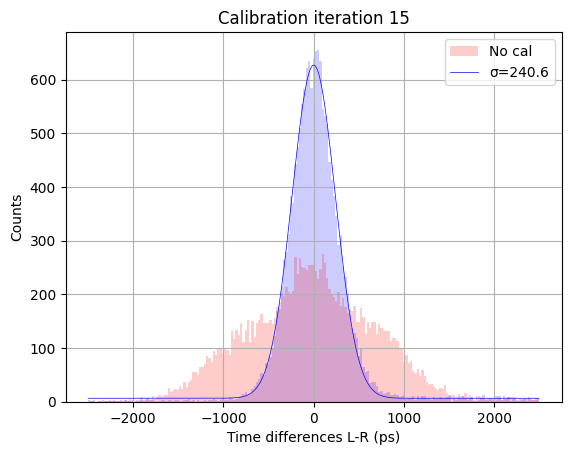

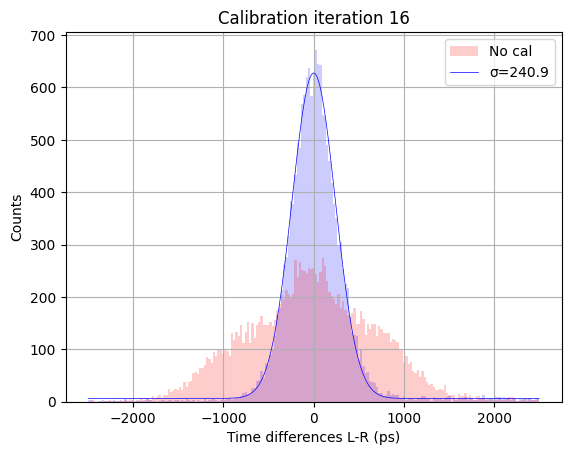

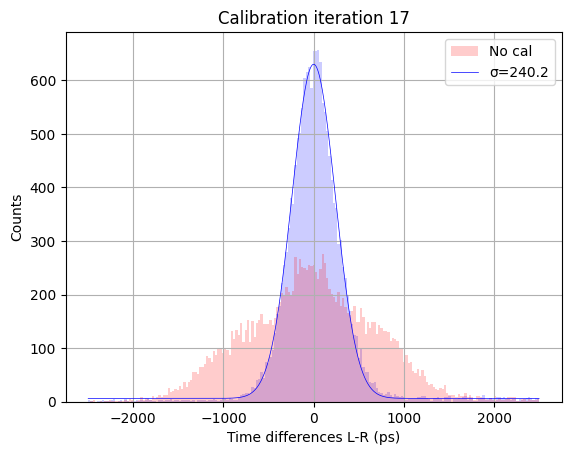

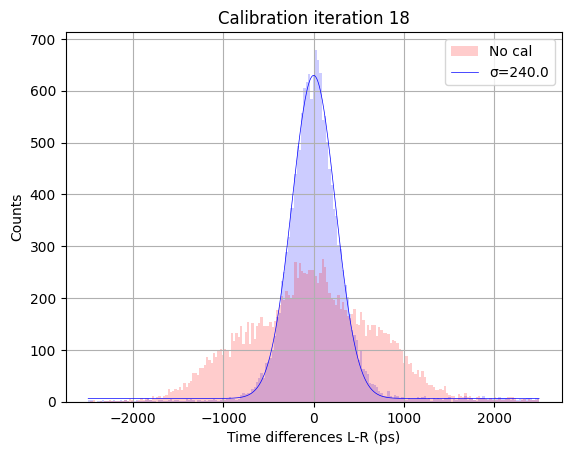

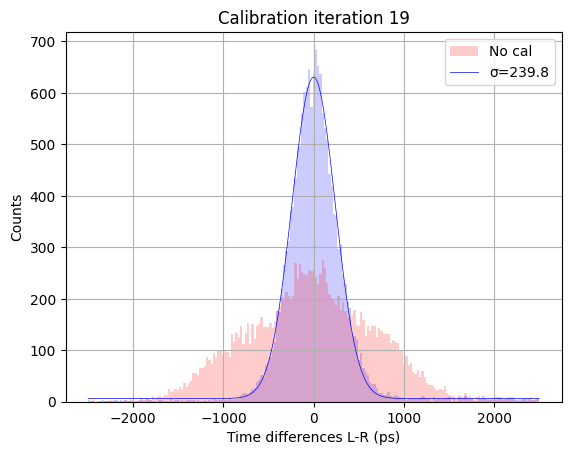

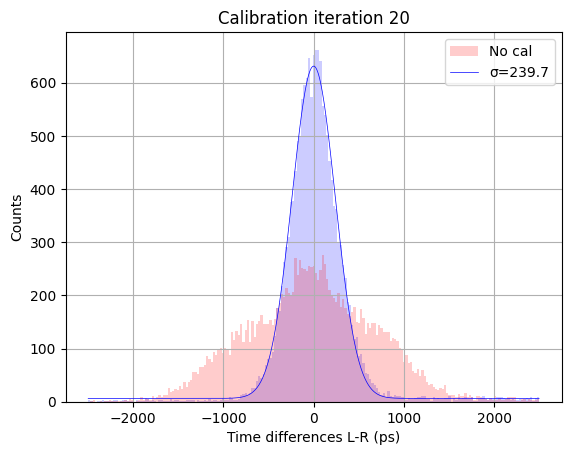

In [ ]:
bins = np.linspace(-2500, 2500, 200) # Consistent histogram bins
bincenters = [(bins[n] + bins[n + 1]) / 2 for n in range(len(bins) - 1)]

# For fitting peaks, gaussian + background
def gaussianbg(x, a, mu, c, bg):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + bg

lookup = np.zeros(256, dtype=np.float32)
def applytimeoffsets(row):
    return row[2] - lookup[row[0] + 128] + lookup[row[1]]

#popts = []
popts2 = []

plt.figure(0)
hist = plt.hist(data[:,2], bins = bins, color = 'red', alpha = 0.2)[0]
popt, pcov = curve_fit(gaussianbg, bincenters, hist)
#popts.append(popt)
popts2.append(popt)
plt.plot(np.linspace(-2500, 2500, 500), gaussianbg(np.linspace(-2500, 2500, 500), *popt), color = 'red', linewidth = 0.5, label = f'σ={popt[2]}')
plt.grid()
plt.legend()
plt.title('No calibration')
plt.xlabel('Time differences L-R (ps)')
plt.ylabel('Counts')
if not os.path.exists(image_out_dir):
    os.makedirs(image_out_dir)
plt.savefig(os.path.join(image_out_dir, 'it0all.png'))

for it in range(num_tsvs):
    num_overflow = 0
    # Load corresponding lookup table
    lookup = np.genfromtxt(os.path.join(tsv_dir, f'time_offset_calibrationit{it+1}.tsv'), delimiter = '\t')[:,4]
    # Loop through data and apply mimic calibration, keeping time differences in timediffs
    timediffs = np.zeros(num_rows, dtype = np.int16)
    writehead = 0
    for i in tqdm(range(0, num_rows, 1000000), desc = 'Read chunk', leave = False):
        chunk = np.copy(data[i:i+1000000])
        for row in chunk:
            try:
                timediffs[writehead] = applytimeoffsets(row)
                writehead += 1
            except:
                timediffs[writehead] = 0
                writehead += 1
                num_overflow += 1
    print(f'Number of overflows: {num_overflow}')

    # Histogram time diffs and fit gaussian, keep fit information
    plt.figure(it+1)
    hist = plt.hist(timediffs, bins = bins, color = 'blue', alpha = 0.2)[0]
    plt.hist(data[:,2], bins = bins, color = 'red', alpha = 0.2, label='No cal') # No cal for comparison
    popt, pcov = curve_fit(gaussianbg, bincenters, hist, p0 = [300, 0, 500, 10])
    #popts.append(popt)
    popts2.append(popt)
    plt.plot(np.linspace(-2500, 2500, 500), gaussianbg(np.linspace(-2500, 2500, 500), *popt), color = 'blue', linewidth = 0.5, label = f'σ={round(popt[2],1)}')
    plt.grid()
    plt.legend()
    plt.title(f'Calibration iteration {it+1}')
    plt.xlabel('Time differences L-R (ps)')
    plt.ylabel('Counts')
    #plt.savefig(os.path.join(image_out_dir, f'it{it+1}all.png'))

    


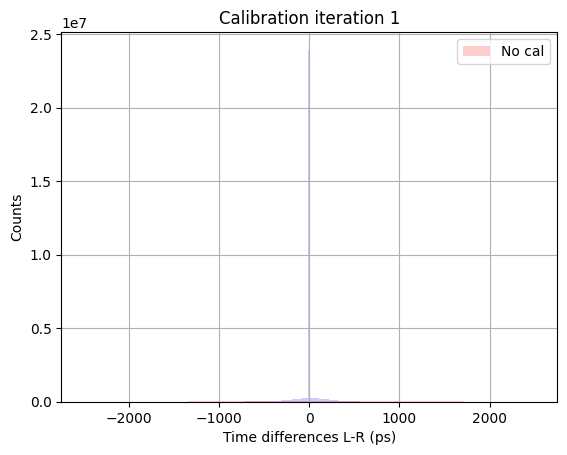

In [ ]:
# Load corresponding lookup table
lookup = np.zeros(6144, dtype=np.float32)
def applytimeoffsets(row):
    return row[2] - lookup[row[0] + 3072] + lookup[row[1]]

lookup = np.genfromtxt(os.path.join(tsv_dir, f'time_offset_calibrationit3.tsv'), delimiter = '\t')[:,4]
# Loop through data and apply mimic calibration, keeping time differences in timediffs
timediffs = np.zeros(num_rows, dtype = np.int16)
writehead = 0
for i in tqdm(range(0, num_rows, 1000000), desc = 'Read chunk', leave = False):
    chunk = np.copy(data[i:i+1000000])
    for row in chunk:
        timediffs[writehead] = applytimeoffsets(row)
        writehead += 1
# Histogram time diffs and fit gaussian, keep fit information
plt.figure(it+1)
hist = plt.hist(timediffs, bins = bins, color = 'blue', alpha = 0.2)[0]
plt.hist(data[:,2], bins = bins, color = 'red', alpha = 0.2, label='No cal') # No cal for comparison
#popt, pcov = curve_fit(gaussianbg, bincenters, hist)
#popts.append(popt)
#plt.plot(np.linspace(-2500, 2500, 500), gaussianbg(np.linspace(-2500, 2500, 500), *popt), color = 'blue', linewidth = 0.5, label = f'σ={round(popt[2],1)}')
plt.grid()
plt.legend()
plt.title(f'Calibration iteration {it+1}')
plt.xlabel('Time differences L-R (ps)')
plt.ylabel('Counts')
#plt.savefig(os.path.join(image_out_dir, f'it{it+1}all.png'))
plt.show()

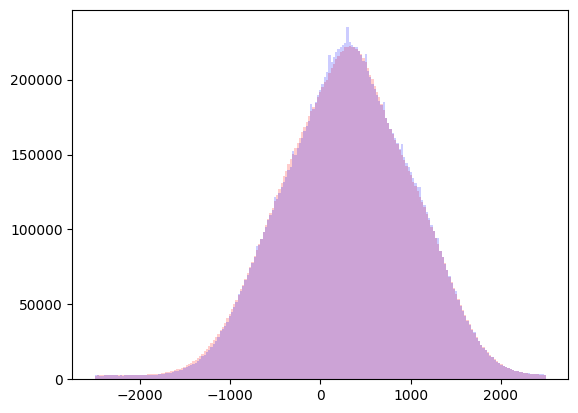

In [36]:
plt.hist(data[:,2] - geomoffsets[data[:,0], data[:,1]], bins = bins, color = 'red', alpha = 0.2)[0]
plt.hist(data[:,2], bins = bins, color = 'blue', alpha = 0.2)[0]
plt.show()

In [66]:
popts = np.asarray(popts)
popts[:,2]

array([695.21677583, 375.74812101, 236.41851496, 182.56494672,
       165.48432427, 160.76054238, 159.52682117, 159.20109864,
       159.1080132 , 159.08064115, 159.07255939])

[1.15041546e+03 1.11945981e+00 7.68964451e+02]
[1.11246032e+03 1.06772563e+00 5.66496077e+02]


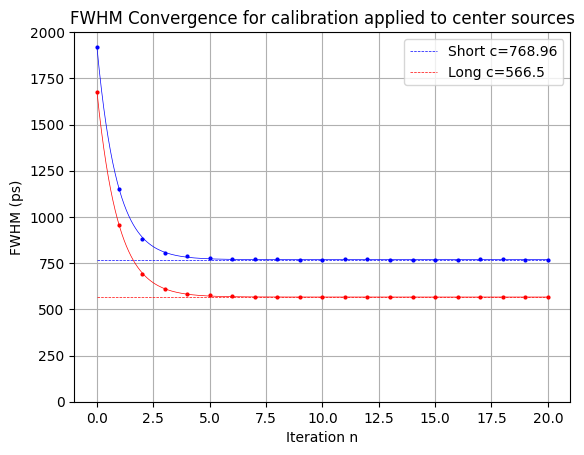

In [23]:
popts = np.asarray(popts)

def expdecay(x, a, b, c):
    return a * np.exp(-b * x) + c

fwhms = np.abs(popts[:,2]) * 2.355
plt.plot(range(num_tsvs + 1),fwhms, 'o', color = 'blue', markersize = 2)
popt, pcov = curve_fit(expdecay, range(num_tsvs + 1), fwhms, p0 = [600, 0.9, 150])
print(popt)
plt.plot(np.linspace(0, num_tsvs, 200), expdecay(np.linspace(0, num_tsvs, 200), *popt), color = 'blue', linewidth = 0.5)
plt.hlines(popt[2], 0, num_tsvs, color =  'blue', linestyle = 'dashed', linewidth = 0.5, label = f'Short c={round(popt[2], 2)}')

popts2 = np.asarray(popts2)
fwhms2 = np.abs(popts2[:,2]) * 2.355
plt.plot(range(num_tsvs + 1),fwhms2, 'o', color = 'red', markersize = 2)
popt2, pcov2 = curve_fit(expdecay, range(num_tsvs + 1), fwhms2, p0 = [600, 0.9, 150])
print(popt2)
plt.plot(np.linspace(0, num_tsvs, 200), expdecay(np.linspace(0, num_tsvs, 200), *popt2), color = 'red', linewidth = 0.5)
plt.hlines(popt2[2], 0, num_tsvs, color =  'red', linestyle = 'dashed', linewidth = 0.5, label = f'Long c={round(popt2[2], 2)}')

plt.ylim(0, 2000)
plt.legend()
plt.title('FWHM Convergence for calibration applied to center sources')
plt.ylabel('FWHM (ps)')
plt.xlabel('Iteration n')
plt.grid()

In [ ]:
del data